In [82]:
import os
import numpy as np
import nibabel as nib
import torch
import torch.nn.functional as F

from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

In [83]:
def load_nifti(path):
    return nib.load(path).get_fdata()

def preprocess(vol):
    vol = resize(vol, (16,16,16))
    vol = (vol - np.mean(vol)) / (np.std(vol) + 1e-5)
    return vol

In [84]:
def extract_features(vol):
    return np.concatenate([
        np.mean(vol, axis=(1,2)),
        np.mean(vol, axis=(0,2)),
        np.mean(vol, axis=(0,1)),
        [np.std(vol)]   # 🔥 add global variation
    ])

In [85]:
def load_dataset(paths):
    volumes, labels = [], []

    label_map = {
        "healthy": 0,
        "alzheimer_early": 1,
        "alzheimer_diagnosed": 1,
        "parkinson_early": 2,
        "parkinson_diagnosed": 2
    }

    for label, folder in paths.items():
        for f in os.listdir(folder):
            if f.endswith(".nii") or f.endswith(".nii.gz"):
                v = preprocess(load_nifti(os.path.join(folder, f)))
                volumes.append(v)
                labels.append(label_map[label])

    return volumes, np.array(labels)

In [86]:
paths = {
    "healthy": "alzimers/cn",
    "alzheimer_early": "alzimers/mci",
    "alzheimer_diagnosed": "alzimers/ad",
    "parkinson_early": "parkinsons/detect",
    "parkinson_diagnosed": "parkinsons/disease"
}

volumes, labels = load_dataset(paths)

In [87]:
train_idx, test_idx = train_test_split(
    list(range(len(labels))),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [88]:
train_mask = torch.zeros(len(labels), dtype=torch.bool)
test_mask = torch.zeros(len(labels), dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

In [118]:
features = np.array([extract_features(v) for v in volumes])

scaler = StandardScaler()
features = scaler.fit_transform(features)

features = torch.tensor(features, dtype=torch.float)
labels = torch.tensor(labels, dtype=torch.long)
# 🔥 Oversampling to strengthen disease learning
X_list = features.tolist()
y_list = labels.tolist()

for i in range(len(y_list)):
    if y_list[i] != 0:   # duplicate disease classes (1 & 2)
        X_list.append(X_list[i])
        y_list.append(y_list[i])

# convert back
features = torch.tensor(X_list, dtype=torch.float)
labels = torch.tensor(y_list, dtype=torch.long)

C:\Users\srivi\AppData\Local\Temp\ipykernel_79264\3531879769.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.long)


In [90]:
# rebuild graph AFTER final features & labels
sim = cosine_similarity(features.numpy())

edge_index = []
edge_weight = []

for i in range(len(features)):
    for j in range(len(features)):
        if i != j and sim[i][j] > 0.6:
            edge_index.append([i, j])
            edge_weight.append(sim[i][j])

edge_index = torch.tensor(edge_index).t().contiguous()
edge_weight = torch.tensor(edge_weight, dtype=torch.float)

graph_data = Data(
    x=features,
    edge_index=edge_index,
    edge_weight=edge_weight,
    y=labels
)

In [91]:
train_idx, test_idx = train_test_split(
    list(range(len(labels))),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_mask = torch.zeros(len(labels), dtype=torch.bool)
test_mask = torch.zeros(len(labels), dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

In [92]:
graph_data = Data(
    x=features,
    edge_index=edge_index,
    edge_weight=edge_weight,
    y=labels
)

In [108]:
class GNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(49, 32)
        self.conv2 = GCNConv(32, 16)
        self.conv3 = GCNConv(16, 8)
        self.fc = torch.nn.Linear(8, 3)

    def forward(self, data):
        x = F.relu(self.conv1(data.x, data.edge_index, data.edge_weight))
        x = F.dropout(x, p=0.4, training=self.training)

        x = F.relu(self.conv2(x, data.edge_index, data.edge_weight))
        x = F.dropout(x, p=0.3, training=self.training)

        x = F.relu(self.conv3(x, data.edge_index, data.edge_weight))
        x = self.fc(x)

        return F.log_softmax(x, dim=1)

In [109]:
model = GNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003, weight_decay=1e-4)
for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    out = model(graph_data)
    loss = F.nll_loss(out[train_mask], labels[train_mask])
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 1.1905975341796875
Epoch: 10 Loss: 0.8144293427467346
Epoch: 20 Loss: 0.6440220475196838
Epoch: 30 Loss: 0.5563002228736877
Epoch: 40 Loss: 0.5090489983558655
Epoch: 50 Loss: 0.4575505554676056
Epoch: 60 Loss: 0.44791731238365173
Epoch: 70 Loss: 0.4271096885204315
Epoch: 80 Loss: 0.4470418393611908
Epoch: 90 Loss: 0.3896714448928833
Epoch: 100 Loss: 0.3931465148925781
Epoch: 110 Loss: 0.3836093842983246
Epoch: 120 Loss: 0.37673673033714294
Epoch: 130 Loss: 0.3798527121543884
Epoch: 140 Loss: 0.3672345280647278
Epoch: 150 Loss: 0.36896759271621704
Epoch: 160 Loss: 0.36272478103637695
Epoch: 170 Loss: 0.3668779730796814
Epoch: 180 Loss: 0.35840722918510437
Epoch: 190 Loss: 0.3598746061325073


In [110]:
model.eval()
out = model(graph_data)

pred = out[test_mask].argmax(dim=1)
acc = (pred == labels[test_mask]).sum().item() / test_mask.sum().item()

print("Test Accuracy:", acc)

Test Accuracy: 0.8


In [111]:
from sklearn.metrics import classification_report

print(classification_report(
    labels[test_mask].numpy(),
    pred.numpy()
))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.75      1.00      0.86        12
           2       0.86      1.00      0.92        12

    accuracy                           0.80        30
   macro avg       0.54      0.67      0.59        30
weighted avg       0.64      0.80      0.71        30



c:\Users\srivi\OneDrive\Pictures\Desktop\brain\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\srivi\OneDrive\Pictures\Desktop\brain\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\srivi\OneDrive\Pictures\Desktop\brain\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 3.0 MB/s eta 0:00:03
   --- ------------------------------------ 0.8/8.1 MB 3.0 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.1 MB 1.9 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.1 MB 1.7 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.1 MB 1.8 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.1 MB 1.7 MB/s eta 0:00:04
   ---------------- ----------------------- 3.4/8.1 MB 2.2 MB/s eta 0:00:03
   ------------------- -------------------- 3.9/8.1 MB 2.2 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.1 MB 2.2 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.1 MB 2.3 MB/s 

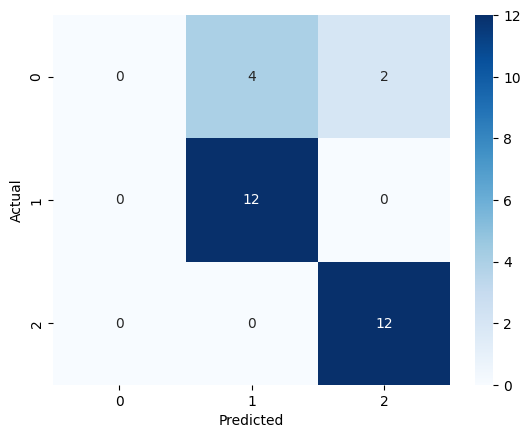

In [100]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels[test_mask].numpy(), pred.numpy())

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [101]:
from sklearn.metrics import f1_score

f1 = f1_score(labels[test_mask], pred, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.712087912087912


In [102]:
from sklearn.metrics import precision_score, recall_score

print("Precision:", precision_score(labels[test_mask], pred, average='weighted'))
print("Recall:", recall_score(labels[test_mask], pred, average='weighted'))

Precision: 0.6428571428571428
Recall: 0.8


c:\Users\srivi\OneDrive\Pictures\Desktop\brain\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [103]:
probs = torch.exp(out[test_mask])
confidence, pred_conf = probs.max(dim=1)

mask = confidence > 0.6

acc_conf = (pred_conf[mask] == labels[test_mask][mask]).sum().item() / mask.sum().item()

print("High-confidence accuracy:", acc_conf)


High-confidence accuracy: 0.8


In [104]:
def predict_new(file_path):
    # load + preprocess
    vol = preprocess(load_nifti(file_path))
    
    # extract features (same as training)
    feat = extract_features(vol)
    
    # scale (IMPORTANT: use same scaler)
    feat = scaler.transform([feat])
    feat = torch.tensor(feat, dtype=torch.float)

    # create graph node (single node connected to itself)
    edge_index = torch.tensor([[0], [0]], dtype=torch.long)
    edge_weight = torch.tensor([1.0], dtype=torch.float)

    data = Data(
        x=feat,
        edge_index=edge_index,
        edge_weight=edge_weight
    )

    # prediction
    model.eval()
    out = model(data)
    pred = out.argmax(dim=1).item()

    return pred

In [122]:
result = predict_new("test/sample.nii")
print("Predicted class:", result)

Predicted class: 2


In [112]:
probs = torch.exp(out[test_mask]).detach().numpy()

roc = roc_auc_score(
    labels[test_mask].numpy(),
    probs,
    multi_class='ovr'
)

print("ROC AUC:", roc)

ROC AUC: 0.8302469135802468


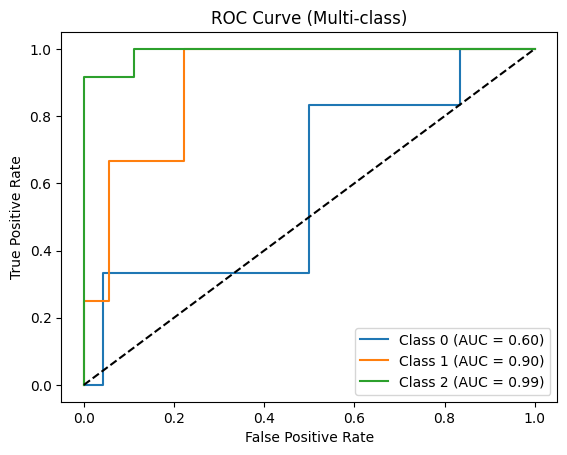

In [114]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

n_classes = probs.shape[1]

for i in range(n_classes):
    fpr, tpr, _ = roc_curve((y_true == i).astype(int), probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()
plt.show()